In [1]:
import requests
import pandas as pd
import csv
import zipfile
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as sm # OLS model estimation
import statistics
from scipy import stats
import math

# suppress scientific notation
pd.set_option('display.float_format', lambda x: '%.4f' % x) 

print(f"Your current working directory is: {Path.cwd()}")

Your current working directory is: /Users/dima


# Retrieve data


## Download deposits amounts and number of deposits from Banca d'Italia 

Deposits amounts: 
https://infostat.bancaditalia.it/inquiry/home?spyglass/taxo:CUBESET=/PUBBL_00/PUBBL_00_07/PUBBL_00_07_03/TDB20290&ITEMSELEZ=TDB20290_52000100:true&OPEN=false/&ep:LC=EN&COMM=BANKITALIA&ENV=LIVE&CTX=DIFF&IDX=2&/view:CUBEIDS=TDB20290_52000100
Counterparty institutional sector: Households.
Customer location: Italy.


Number of deposits: 
https://infostat.bancaditalia.it/inquiry/home?spyglass/taxo:CUBESET=/PUBBL_00/PUBBL_00_07/PUBBL_00_07_06/PUBBL_00_07_06_02/TFR10283&ITEMSELEZ=TFR10283_5833004:true&OPEN=false/&ep:LC=EN&COMM=BANKITALIA&ENV=LIVE&CTX=DIFF&IDX=2&/view:CUBEIDS=TFR10283_5833004

In [2]:
#download data from Banca d'Italia

cubes = ["TFR10283", "TDB20290"]
#TFR10283_5833004 for number of current accounts
#TDB20290_52000100 for the deposit amounts

base_url = (
    "https://a2a.bancaditalia.it/infostat/dataservices/export/"
    "EN/CSV/ALL/CUBE/BANKITALIA/DIFF/{cube}"
)

out_dir = Path("data/raw/bancaditalia")
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Files are saved at following path: {Path.cwd() / out_dir }")

for cube in cubes:
    url = base_url.format(cube=cube)
    r = requests.get(url, timeout=60)
    r.raise_for_status()

    zip_path = out_dir / f"{cube}.zip"
    zip_path.write_bytes(r.content)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir / cube)

Files are saved at following path: /Users/dima/data/raw/bancaditalia


In [3]:
def detect_encoding(file_path: Path) -> str:
    """
    Common encodings used in European CSV exports.
    """
    encodings = ["utf-8-sig", "utf-8", "cp1252", "latin1"]

    for enc in encodings:
        try:
            file_path.read_text(encoding=enc)
            return enc
        except UnicodeDecodeError:
            continue

    return "latin1"

In [4]:
def detect_separator(file_path: Path, encoding: str) -> str:
    """
    Detect whether the CSV uses comma, semicolon, tab, etc.
    """
    sample = file_path.read_text(encoding=encoding, errors="ignore")[:5000]

    try:
        dialect = csv.Sniffer().sniff(sample, delimiters=[",", ";", "\t", "|"])
        return dialect.delimiter
    except csv.Error:
        return ";"


In [5]:
def read_csv_auto(file_path: Path) -> pd.DataFrame:
    """
    Read the CSV detecting encoding and separator.
    """
    encoding = detect_encoding(file_path)
    sep = detect_separator(file_path, encoding)

    df = pd.read_csv(
        file_path,
        sep=sep,
        encoding=encoding,
        dtype=str,
        low_memory=False
    )

    df.columns = (
        df.columns
        .str.strip()
        .str.replace(" ", "_")
        .str.replace("-", "_")
        .str.lower()
    )

    return df


In [6]:
def load_bancaditalia_cube(cube: str, raw_dir: Path = out_dir) -> dict:
    """
    Load all CSV files extracted for one Banca d'Italia cube.

    Example cube:
        TFR20269
        TFR10283
        TFR30980

    Returns:
        {
            "data": DataFrame or None,
            "legend": DataFrame or None,
            "domain": DataFrame or None,
            "structure": DataFrame or None,
            "other": {filename: DataFrame}
        }
    """
    cube_dir = raw_dir / cube

    if not cube_dir.exists():
        raise FileNotFoundError(f"Folder not found: {cube_dir}")

    csv_files = list(cube_dir.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {cube_dir}")

    result = {
        "data": None,
        "legend": None,
        "domain": None,
        "structure": None,
        "other": {}
    }

    for file_path in csv_files:
        name = file_path.stem.lower()
        df = read_csv_auto(file_path)

        if "legend" in name:
            result["legend"] = df
        elif "domain" in name:
            result["domain"] = df
        elif "structure" in name:
            result["structure"] = df
        elif "data" in name or name.lower() == cube.lower():
            result["data"] = df
        else:
            result["other"][file_path.name] = df

    return result

In [7]:
cubes = cubes

bdi = {}

for cube in cubes:
    bdi[cube] = load_bancaditalia_cube(cube)

    print(f"\n{cube}")
    print("Data shape:", None if bdi[cube]["data"] is None else bdi[cube]["data"].shape)
    print("Legend shape:", None if bdi[cube]["legend"] is None else bdi[cube]["legend"].shape)
    print("Domain shape:", None if bdi[cube]["domain"] is None else bdi[cube]["domain"].shape)
    print("Structure shape:", None if bdi[cube]["structure"] is None else bdi[cube]["structure"].shape)
    print("Other files:", list(bdi[cube]["other"].keys()))


TFR10283
Data shape: (7215, 6)
Legend shape: (14, 3)
Domain shape: (160, 3)
Structure shape: (20, 6)
Other files: []

TDB20290
Data shape: (523082, 7)
Legend shape: (14, 3)
Domain shape: (190, 3)
Structure shape: (21, 6)
Other files: []


In [8]:
for cube in cubes:
    print(f"\n{cube} columns:")
    print(bdi[cube]["data"].columns.tolist())
    display(bdi[cube]["data"].head())


TFR10283 columns:
['data_oss', 'ente_segn', 'fenec', 'loc_sport', 'valore', 'status']


,data_oss,ente_segn,fenec,loc_sport,valore,status
0,2025-12-31,1100010,1041810,ITC18,7846250,NaN
1,2025-12-31,1100010,1041810,ITI35,2465743,NaN
2,2025-12-31,1100010,1041810,ITC14,2837751,NaN
3,2025-12-31,1100010,1041810,ITF51,4192127,NaN
4,2025-12-31,1100010,1041810,ITI31,7494794,NaN



TDB20290 columns:
['data_oss', 'ente_segn', 'fenec', 'loc_ctp', 'set_ctp', 'valore', 'status']


,data_oss,ente_segn,fenec,loc_ctp,set_ctp,valore,status
0,2026-04-30,1070001,52000100,ITF33,S129,130,NaN
1,2026-04-30,1070001,52000100,ITI16,S11001,88559,NaN
2,2026-04-30,1070001,52000100,ITF63,S11BI32,661032,NaN
3,2026-04-30,1070001,52000100,ITF34,SBI59,11434948,NaN
4,2026-04-30,1070001,52000100,ITG2F,600,8385965,NaN


In [9]:
tfr10283 = bdi["TFR10283"]["data"]   # number of positions of current accounts 
TDB20290 = bdi["TDB20290"]["data"]   # deposit amounts by counterpary, sector, geography

In [10]:
#fenec=5833004: number of current accounts in Italy. only annual data
#https://infostat.bancaditalia.it/inquiry/home?spyglass/taxo:CUBESET=/PUBBL_00/PUBBL_00_07/PUBBL_00_07_06/PUBBL_00_07_06_02/TFR10283&ITEMSELEZ=TFR10283_5833004:true&OPEN=false/&ep:LC=EN&COMM=BANKITALIA&ENV=LIVE&CTX=DIFF&IDX=2&/view:CUBEIDS=TFR10283_5833004
tfr10283_filtered = tfr10283[
    (tfr10283["loc_sport"].astype(str).str.strip() == "IT") &
    (tfr10283["fenec"].astype(str).str.strip() == "5833004")
].copy()

tfr10283_filtered = tfr10283_filtered.rename(columns={"valore": "n_of_accounts"})

tfr10283_filtered["data_oss"] = pd.to_datetime(tfr10283_filtered["data_oss"])
tfr10283_filtered["n_of_accounts"] = pd.to_numeric(tfr10283_filtered["n_of_accounts"], errors="coerce")

tfr10283_filtered

,data_oss,ente_segn,fenec,loc_sport,n_of_accounts,status
202,2025-12-31,1100010,5833004,IT,53073989,NaN
749,2024-12-31,1100010,5833004,IT,48110106,NaN
1185,2023-12-31,1100010,5833004,IT,46915344,NaN
1472,2022-12-31,1100010,5833004,IT,46033151,NaN
1873,2021-12-31,1100010,5833004,IT,45108058,NaN
2017,2020-12-31,1100010,5833004,IT,43988602,NaN
2517,2019-12-31,1100010,5833004,IT,42498357,NaN
3034,2018-12-31,1100010,5833004,IT,41611233,NaN
3336,2017-12-31,1100010,5833004,IT,40978639,NaN
3789,2016-12-31,1100010,5833004,IT,40174015,NaN


In [11]:
# number of accounts are reported annually -> convert to monthly data, then interpolate missing data

# Create full monthly end-of-month date range
rate_start_date = tfr10283_filtered["data_oss"].min()
rate_end_date   = tfr10283_filtered["data_oss"].max()

monthly_dates = pd.date_range(
    start=rate_start_date,
    end=rate_end_date,
    freq=pd.offsets.MonthEnd()
)

# Reindex to monthly end-of-month dates
tfr10283_filtered = (
    tfr10283_filtered.set_index("data_oss")
        .reindex(monthly_dates)
        .rename_axis("data_oss")
        .reset_index()
)

# Linear interpolation of missing values
value_columns = [col for col in tfr10283_filtered.columns if col == "n_of_accounts"]
tfr10283_filtered[value_columns] = tfr10283_filtered[value_columns].interpolate(method="linear")

tfr10283_filtered

,data_oss,ente_segn,fenec,loc_sport,n_of_accounts,status
0,2008-12-31,1100010,5833004,IT,35804872.0000,NaN
1,2009-01-31,NaN,NaN,NaN,35713611.8333,NaN
2,2009-02-28,NaN,NaN,NaN,35622351.6667,NaN
3,2009-03-31,NaN,NaN,NaN,35531091.5000,NaN
4,2009-04-30,NaN,NaN,NaN,35439831.3333,NaN
...,...,...,...,...,...,...
200,2025-08-31,NaN,NaN,NaN,51419361.3333,NaN
201,2025-09-30,NaN,NaN,NaN,51833018.2500,NaN
202,2025-10-31,NaN,NaN,NaN,52246675.1667,NaN
203,2025-11-30,NaN,NaN,NaN,52660332.0833,NaN


In [12]:
#retrieve data for houselhold's deposits
TDB20290_filtered = TDB20290[
    (TDB20290["loc_ctp"].astype(str).str.strip() == "IT") &
    (TDB20290["set_ctp"].astype(str).str.strip().isin(["S14BI2", "600"]))  #Producer households (up to 5 employees):S14BI2 + Consumer households:600 = Households:S14
].copy()

TDB20290_filtered = TDB20290_filtered.rename(columns={"valore": "amount"})


In [13]:
TDB20290_filtered

,data_oss,ente_segn,fenec,loc_ctp,set_ctp,amount,status
1803,2026-04-30,1070001,52000100,IT,S14BI2,90402100,NaN
2006,2026-04-30,1070001,52000100,IT,600,1162793126,NaN
3247,2026-03-31,1070001,52000100,IT,600,1161048575,NaN
4066,2026-03-31,1070001,52000100,IT,S14BI2,88516602,NaN
7352,2026-02-28,1070001,52000100,IT,600,1169466871,NaN
...,...,...,...,...,...,...,...
517194,2011-03-31,1070001,52000100,IT,600,767669163,NaN
519868,2011-02-28,1070001,52000100,IT,S14BI2,45252889,NaN
519991,2011-02-28,1070001,52000100,IT,600,774460123,NaN
521116,2011-01-31,1070001,52000100,IT,600,774550982,NaN


In [14]:
#sum the deposits of Producer households (up to 5 employees) and Consumer households 
TDB20290_filtered["data_oss"] = pd.to_datetime(TDB20290_filtered["data_oss"])
TDB20290_filtered["amount"] = pd.to_numeric(TDB20290_filtered["amount"], errors="coerce") *1000 #original data are in thousands

TDB20290_filtered = (
    TDB20290_filtered
    .groupby("data_oss", as_index=False)["amount"]
    .sum()
    .sort_values("data_oss")
)

TDB20290_filtered
#https://infostat.bancaditalia.it/inquiry/home?spyglass/taxo:CUBESET=/PUBBL_00/PUBBL_00_07/PUBBL_00_07_03/TDB20290&ITEMSELEZ=TDB20290_52000100:true&OPEN=false/&ep:LC=EN&COMM=BANKITALIA&ENV=LIVE&CTX=DIFF&IDX=2&/view:CUBEIDS=TDB20290_52000100

,data_oss,amount
0,2011-01-31,819174460000
1,2011-02-28,819713012000
2,2011-03-31,812818655000
3,2011-04-30,813558974000
4,2011-05-31,811428024000
...,...,...
179,2025-12-31,1249289895000
180,2026-01-31,1256438574000
181,2026-02-28,1258255689000
182,2026-03-31,1249565177000


In [15]:
print((tfr10283_filtered["data_oss"]).dtype)
print((TDB20290_filtered["data_oss"]).dtype)

datetime64[ns]
datetime64[ns]


In [16]:
#merge datasets
input_table = pd.merge(
    TDB20290_filtered,
    tfr10283_filtered,
    on="data_oss",
    how="left"
)

input_table = input_table.sort_values("data_oss").reset_index(drop=True)
print((tfr10283_filtered["data_oss"]).dtype)
print((TDB20290_filtered["data_oss"]).dtype)

datetime64[ns]
datetime64[ns]


In [17]:
input_table = input_table[["data_oss", "amount", "n_of_accounts"]]

# Remove rows with NaN
input_table = input_table.dropna(subset=["amount", "n_of_accounts"])
input_table

,data_oss,amount,n_of_accounts
0,2011-01-31,819174460000,35120648.1667
1,2011-02-28,819713012000,35169276.3333
2,2011-03-31,812818655000,35217904.5000
3,2011-04-30,813558974000,35266532.6667
4,2011-05-31,811428024000,35315160.8333
...,...,...,...
175,2025-08-31,1231230265000,51419361.3333
176,2025-09-30,1232227756000,51833018.2500
177,2025-10-31,1226414269000,52246675.1667
178,2025-11-30,1230886279000,52660332.0833


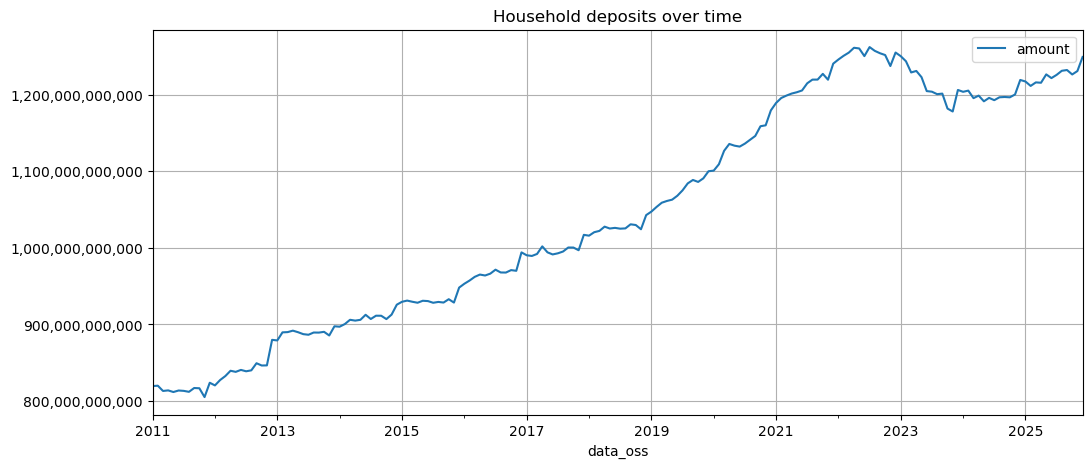

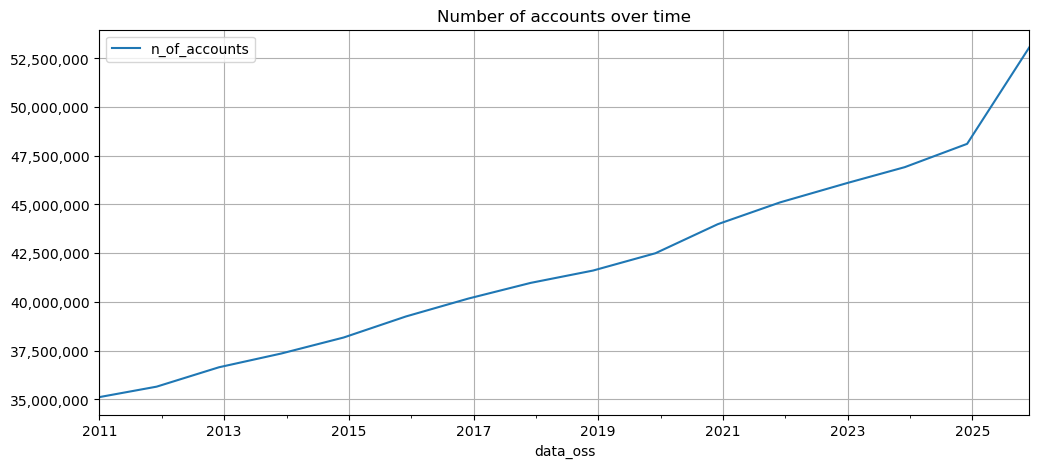

In [18]:
# Plot both measures
import matplotlib.ticker as mticker
ax = input_table.plot(
    x="data_oss",
    y="amount",
    figsize=(12, 5),
    title="Household deposits over time"
)

ax.ticklabel_format(style="plain", axis="y")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.grid(True)
plt.show()

ax = input_table.plot(
    x="data_oss",
    y="n_of_accounts",
    figsize=(12, 5),
    title="Number of accounts over time"
)

ax.ticklabel_format(style="plain", axis="y")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.grid(True)
plt.show()

In [19]:
input_table = input_table.rename(columns={"data_oss": "DATE"})

## Retrieve the market data and customer rates 

The data are the same as of customer rate model. 4 input files must be placed in the working directory.

Input files: 
* ita_10y.csv
* ger_10y.csv
* euribor1M.csv
* rate_NMD.xlsx

In [20]:
main_dir = Path.cwd()

inputs = {
    "Italy_10Y": "ita_10y.csv",       #https://data.ecb.europa.eu/data/datasets/IRS/IRS.M.IT.L.L40.CI.0000.EUR.N.Z
    "Germany_10Y": "ger_10y.csv",     #https://data.ecb.europa.eu/data/datasets/IRS/IRS.M.DE.L.L40.CI.0000.EUR.N.Z
    "Euribor_1M": "euribor1M.csv",    #https://data.ecb.europa.eu/data/datasets/FM/FM.M.U2.EUR.RT.MM.EURIBOR1MD_.HSTA
    "customer_rate": "rate_NMD.xlsx", #https://infostat.bancaditalia.it/inquiry/home?spyglass/taxo:CUBESET=/PUBBL_00/PUBBL_00_07/PUBBL_00_07_03/TDB20290&ITEMSELEZ=TDB20290_52000100:true&OPEN=false/&ep:LC=EN&COMM=BANKITALIA&ENV=LIVE&CTX=DIFF&IDX=2&/view:CUBEIDS=TFR30970_40099900
}

print(f"Please place the input files in this folder:\n{main_dir}")

#check for missing files
for series_name, file_name in inputs.items():
    file_path = main_dir / file_name

    if not file_path.exists():
        warnings.warn(f'Missing file: "{file_name}" in folder {main_dir}')
        

Please place the input files in this folder:
/Users/dima


### Retrieve customer rates 


In [21]:
rate_NMD = "rate_NMD.xlsx"
input_file = main_dir / rate_NMD

if not input_file.exists():
    print(f'Input file not found. Please place "{rate_NMD}" in: {main_dir}')
else:
    print(f'Found input file:\n{input_file}')


Found input file:
/Users/dima/rate_NMD.xlsx


In [22]:
rate = pd.read_excel(rate_NMD, sheet_name="Report")
rate = rate.dropna(axis=1, how="all")

rate = rate.rename(columns={rate.columns[0]: "DATE"})
rate["DATE"] = pd.to_datetime(rate["DATE"], dayfirst=True)

In [23]:
# Customer rates are reported quarterly -> convert to monthly data, then interpolate missing rates
# Create full monthly end-of-month date range
rate_start_date = rate["DATE"].min()
rate_end_date   = rate["DATE"].max()

monthly_dates = pd.date_range(
    start=rate_start_date,
    end=rate_end_date,
    freq=pd.offsets.MonthEnd()
)

# Reindex to monthly end-of-month dates
rate = (
    rate.set_index("DATE")
        .reindex(monthly_dates)
        .rename_axis("DATE")
        .reset_index()
)

# Linear interpolation of missing values
value_columns = [col for col in rate.columns if col != "DATE"]
rate[value_columns] = rate[value_columns].interpolate(method="linear")

### Retrieve market data 


In [24]:
#Read the market data
print(f"Please place the input files in this folder:\n{main_dir}")

inputs_market = {
    "Italy_10Y": "ita_10y.csv",       #https://data.ecb.europa.eu/data/datasets/IRS/IRS.M.IT.L.L40.CI.0000.EUR.N.Z
    "Germany_10Y": "ger_10y.csv",     #https://data.ecb.europa.eu/data/datasets/IRS/IRS.M.DE.L.L40.CI.0000.EUR.N.Z
    "Euribor_1M": "euribor1M.csv",    #https://data.ecb.europa.eu/data/datasets/FM/FM.M.U2.EUR.RT.MM.EURIBOR1MD_.HSTA
}

#User defined analysis period 
start_date = rate_start_date
end_date = rate_end_date

Please place the input files in this folder:
/Users/dima


In [25]:
#Merge the market data
from functools import reduce
tables = []

for series_name, file_name in inputs_market.items():
    file_path = main_dir / file_name

    if not file_path.exists():
        warnings.warn(f'Missing file: "{file_name}" in folder {main_dir}')
        continue

    df = pd.read_csv(file_path)

    # Drop columns containing "TIME PERIOD"
    df = df.loc[:, ~df.columns.str.contains(r"TIME[ _]PERIOD", case=False, na=False, regex=True)].copy()


    # Rename data column using dictionary key: Italy_10Y, Germany_10Y, Euribor_1M
    value_col = [col for col in df.columns if col != "DATE"][0]
    df = df.rename(columns={value_col: series_name})
    
    df["DATE"] = pd.to_datetime(df["DATE"])
    
    tables.append(df)

if not tables:
    raise FileNotFoundError("None of the input files were found.")

table = reduce(
    lambda left, right: pd.merge(left, right, on="DATE", how="outer"),
    tables
)

table["DATE"] = pd.to_datetime(table["DATE"])

table = table[
    (table["DATE"] >= start_date) &
    (table["DATE"] <= end_date)
]

table = table.sort_values("DATE").reset_index(drop=True)

In [26]:
rate = rate.rename(columns={"Producer households": "customer_rate"})

# Make sure both DATE columns are datetime
table["DATE"] = pd.to_datetime(table["DATE"])
rate["DATE"] = pd.to_datetime(rate["DATE"])

# Merge into a new table
market_data = pd.merge(
    table,
    rate,
    on="DATE",
    how="left"
)

market_data = market_data.sort_values("DATE").reset_index(drop=True)

market_data

,DATE,Italy_10Y,Germany_10Y,Euribor_1M,customer_rate
0,2010-06-30,4.1000,2.5400,0.4464,0.2100
1,2010-07-31,4.0300,2.6200,0.5833,0.2133
2,2010-08-31,3.8000,2.3500,0.6400,0.2167
3,2010-09-30,3.8600,2.3000,0.6181,0.2200
4,2010-10-31,3.8000,2.3500,0.7842,0.2233
...,...,...,...,...,...
182,2025-08-31,3.5400,2.6700,1.8900,0.1633
183,2025-09-30,3.5600,2.6900,1.8972,0.1600
184,2025-10-31,3.4400,2.6200,1.9063,0.1600
185,2025-11-30,3.4600,2.6600,1.9056,0.1600


## Data wrangling on market data and customer rates


In [27]:
# Check total nulls by column
null_check = market_data.isnull().sum()

print(null_check)

DATE             0
Italy_10Y        0
Germany_10Y      0
Euribor_1M       0
customer_rate    0
dtype: int64


In [28]:
# Compute Spread betwem Italian and German bonds
market_data["Spread"] = market_data["Italy_10Y"] - market_data["Germany_10Y"]

# Compute dummy indicating Covid period (feb 2020 - dec 2020)
mask_covid = ((market_data["DATE"] >= "2020-02-28 00:00:00") & (market_data["DATE"] <= "2020-12-31 00:00:00"))
market_data["dCovid"] = 0
market_data.loc[mask_covid, "dCovid"] = 1

In [29]:
market_data[market_data["dCovid"] == 1]

,DATE,Italy_10Y,Germany_10Y,Euribor_1M,customer_rate,Spread,dCovid
116,2020-02-29,0.9600,-0.4700,-0.4732,0.0300,1.4300,1
117,2020-03-31,1.5500,-0.5400,-0.4777,0.0300,2.0900,1
118,2020-04-30,1.8000,-0.4500,-0.4281,0.0300,2.2500,1
119,2020-05-31,1.7600,-0.5200,-0.4643,0.0300,2.2800,1
120,2020-06-30,1.4600,-0.4300,-0.4929,0.0300,1.8900,1
121,2020-07-31,1.2000,-0.5200,-0.5088,0.0300,1.7200,1
122,2020-08-31,1.0300,-0.5200,-0.5173,0.0300,1.5500,1
123,2020-09-30,0.9800,-0.5200,-0.5217,0.0300,1.5000,1
124,2020-10-31,0.7700,-0.6100,-0.5385,0.0300,1.3800,1
125,2020-11-30,0.6600,-0.6100,-0.5414,0.0300,1.2700,1


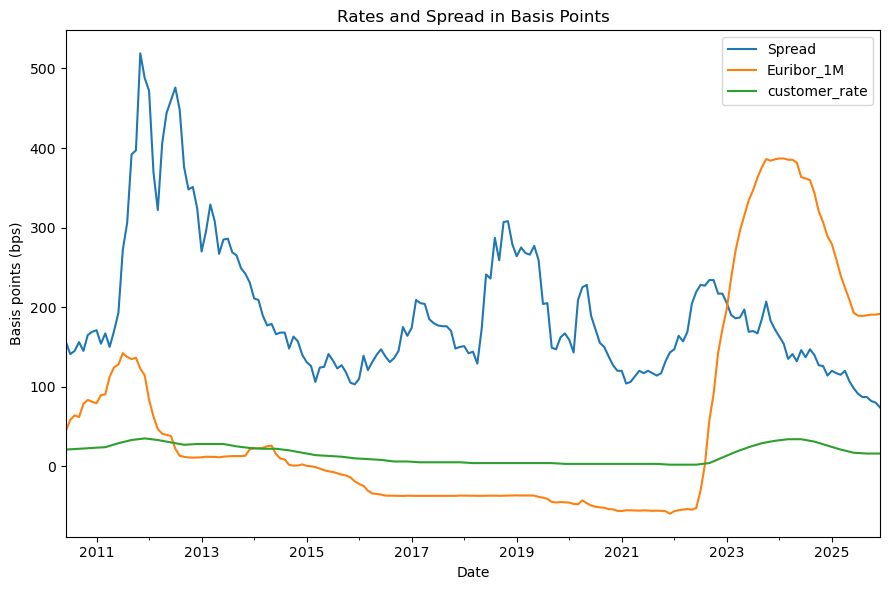

In [30]:
# Plot the data
plot_data = market_data.copy()

plot_data['Spread'] = plot_data['Spread'] * 100
plot_data['Euribor_1M'] = plot_data['Euribor_1M'] * 100
plot_data['customer_rate'] = plot_data['customer_rate'] * 100

ax = plot_data.plot(
    x='DATE',
    y=['Spread', 'Euribor_1M', 'customer_rate'],
    kind='line',
    figsize=(9, 6)
)

ax.set_ylabel('Basis points (bps)')
ax.set_xlabel('Date')
ax.set_title('Rates and Spread in Basis Points')
ax.grid(False)

plt.tight_layout()
plt.show()

In [31]:
market_data[["Euribor_1M", "customer_rate", "Spread"]] = market_data[["Euribor_1M", "customer_rate", "Spread"]] / 100
market_data

,DATE,Italy_10Y,Germany_10Y,Euribor_1M,customer_rate,Spread,dCovid
0,2010-06-30,4.1000,2.5400,0.0045,0.0021,0.0156,0
1,2010-07-31,4.0300,2.6200,0.0058,0.0021,0.0141,0
2,2010-08-31,3.8000,2.3500,0.0064,0.0022,0.0145,0
3,2010-09-30,3.8600,2.3000,0.0062,0.0022,0.0156,0
4,2010-10-31,3.8000,2.3500,0.0078,0.0022,0.0145,0
...,...,...,...,...,...,...,...
182,2025-08-31,3.5400,2.6700,0.0189,0.0016,0.0087,0
183,2025-09-30,3.5600,2.6900,0.0190,0.0016,0.0087,0
184,2025-10-31,3.4400,2.6200,0.0191,0.0016,0.0082,0
185,2025-11-30,3.4600,2.6600,0.0191,0.0016,0.0080,0


## Merge volumes and market data


In [32]:
market_data = market_data[["DATE", "Euribor_1M", "customer_rate", "Spread","dCovid"]] 
market_data

,DATE,Euribor_1M,customer_rate,Spread,dCovid
0,2010-06-30,0.0045,0.0021,0.0156,0
1,2010-07-31,0.0058,0.0021,0.0141,0
2,2010-08-31,0.0064,0.0022,0.0145,0
3,2010-09-30,0.0062,0.0022,0.0156,0
4,2010-10-31,0.0078,0.0022,0.0145,0
...,...,...,...,...,...
182,2025-08-31,0.0189,0.0016,0.0087,0
183,2025-09-30,0.0190,0.0016,0.0087,0
184,2025-10-31,0.0191,0.0016,0.0082,0
185,2025-11-30,0.0191,0.0016,0.0080,0


In [33]:
input_table

,DATE,amount,n_of_accounts
0,2011-01-31,819174460000,35120648.1667
1,2011-02-28,819713012000,35169276.3333
2,2011-03-31,812818655000,35217904.5000
3,2011-04-30,813558974000,35266532.6667
4,2011-05-31,811428024000,35315160.8333
...,...,...,...
175,2025-08-31,1231230265000,51419361.3333
176,2025-09-30,1232227756000,51833018.2500
177,2025-10-31,1226414269000,52246675.1667
178,2025-11-30,1230886279000,52660332.0833


In [34]:
#merge datasets
Data = pd.merge(
    input_table,
    market_data,
    on="DATE",
    how="left"
)

Data

,DATE,amount,n_of_accounts,Euribor_1M,customer_rate,Spread,dCovid
0,2011-01-31,819174460000,35120648.1667,0.0079,0.0023,0.0171,0
1,2011-02-28,819713012000,35169276.3333,0.0089,0.0024,0.0154,0
2,2011-03-31,812818655000,35217904.5000,0.0090,0.0024,0.0167,0
3,2011-04-30,813558974000,35266532.6667,0.0113,0.0026,0.0150,0
4,2011-05-31,811428024000,35315160.8333,0.0124,0.0027,0.0170,0
...,...,...,...,...,...,...,...
175,2025-08-31,1231230265000,51419361.3333,0.0189,0.0016,0.0087,0
176,2025-09-30,1232227756000,51833018.2500,0.0190,0.0016,0.0087,0
177,2025-10-31,1226414269000,52246675.1667,0.0191,0.0016,0.0082,0
178,2025-11-30,1230886279000,52660332.0833,0.0191,0.0016,0.0080,0


# Volume model estimation

The volume (balances) model determines the behavioral liquidity profile of NMDs, in particular:
- the stable component
- the liquidity profile of the stable component, ie the (conservative) decay and the maximum maturity of NMDs balances

The liquidity profile is a decay of stable volumes of NMDs, without the assumptions of roll over or new business.



## Define the target variable (deposit per capita growth rate)
The purpose of modelling the per capita growth rate is to remove any structural breaks in the banking operations, when the significant change in the NMDs balances wouldn't result from real volatility in the accounts but rather from changes in the banking structure.


In [35]:
# Define per-capita balances
Data['Volume_PerCapita'] = Data['amount'] / Data['n_of_accounts']


In [36]:
# Compute log-per-capita balances
Data['LogVolume_PerCapita'] = np.log(Data['Volume_PerCapita'])

In [37]:
# Compute growth rate (delta log)
Data['growth_rate_per_capita'] = Data['LogVolume_PerCapita'] - Data['LogVolume_PerCapita'].shift(1)

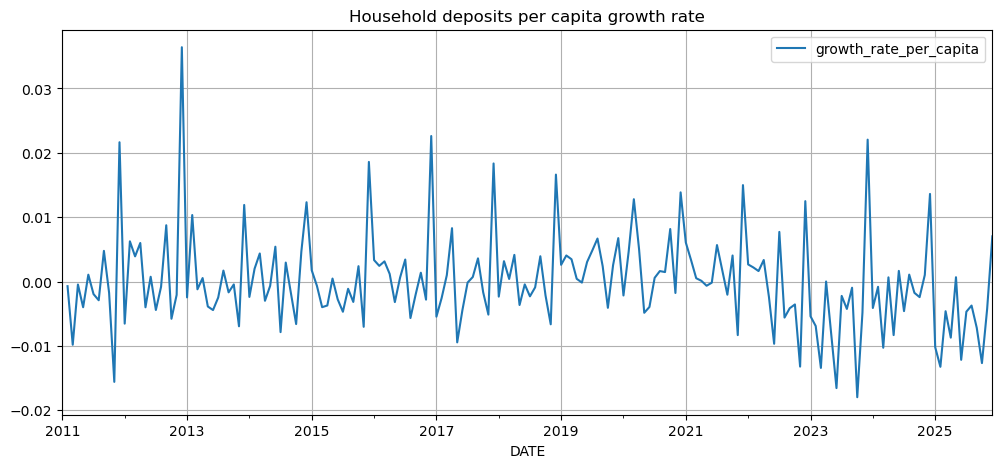

In [38]:
#plot growth rate
ax = Data.plot(
    x="DATE",
    y="growth_rate_per_capita",
    figsize=(12, 5),
    title="Household deposits per capita growth rate"
)
#ax.ticklabel_format(style="plain", axis="y")
#ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.grid(True)
plt.show()

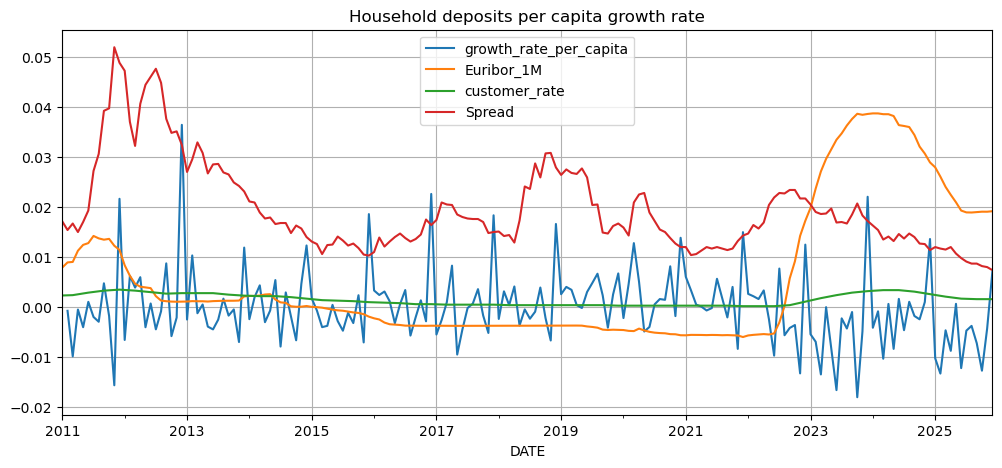

In [39]:
#plot growth rate vs market data and customer rate
ax = Data.plot(
    x="DATE",
    y=['growth_rate_per_capita','Euribor_1M','customer_rate','Spread'], 
    kind="line",
    figsize=(12, 5),
    title="Household deposits per capita growth rate"
)
#ax.ticklabel_format(style="plain", axis="y")
#ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.grid(True)
plt.show()

###
In 2022 there is an apparent negative correlation between deposits' growth rate and the euribor (market rate).
As the market rate rose, customers shifted their allocations from deposits towards more remunerative investments.

## Estimate model

In [40]:
Data

,DATE,amount,n_of_accounts,Euribor_1M,customer_rate,Spread,dCovid,Volume_PerCapita,LogVolume_PerCapita,growth_rate_per_capita
0,2011-01-31,819174460000,35120648.1667,0.0079,0.0023,0.0171,0,23324.5826,10.0573,NaN
1,2011-02-28,819713012000,35169276.3333,0.0089,0.0024,0.0154,0,23307.6451,10.0565,-0.0007
2,2011-03-31,812818655000,35217904.5000,0.0090,0.0024,0.0167,0,23079.6996,10.0467,-0.0098
3,2011-04-30,813558974000,35266532.6667,0.0113,0.0026,0.0150,0,23068.8676,10.0462,-0.0005
4,2011-05-31,811428024000,35315160.8333,0.0124,0.0027,0.0170,0,22976.7614,10.0422,-0.0040
...,...,...,...,...,...,...,...,...,...,...
175,2025-08-31,1231230265000,51419361.3333,0.0189,0.0016,0.0087,0,23944.8767,10.0835,-0.0037
176,2025-09-30,1232227756000,51833018.2500,0.0190,0.0016,0.0087,0,23773.0273,10.0763,-0.0072
177,2025-10-31,1226414269000,52246675.1667,0.0191,0.0016,0.0082,0,23473.5371,10.0636,-0.0127
178,2025-11-30,1230886279000,52660332.0833,0.0191,0.0016,0.0080,0,23374.0698,10.0594,-0.0042


In [41]:
# exclude the first row as the line contains NaN in growth rate
DATA = Data.iloc[1:].reset_index(drop=True)

In [42]:
# estimate model by recursively eliminating the least significant variables 
target = "growth_rate_per_capita"

variables = [
    "Euribor_1M",
    "customer_rate",
    "Spread",
    "dCovid"
]

# Store eliminated variables
eliminated_variables = []

step = 1 

while True:
    if len(variables) > 0:
        formula = target + " ~ " + " + ".join(variables)
    else:
        formula = target + " ~ 1"   # intercept-only model

    # Fit model
    model = sm.ols(formula=formula, data=DATA).fit()

    p_values = model.pvalues.drop("Intercept", errors="ignore")

    # Stop if no variables remain
    if p_values.empty:
        break

    worst_variable = p_values.idxmax()
    worst_pvalue = p_values.max()

    # Stop if all variables are significant at 5%
    if worst_pvalue <= 0.05:
        break

    # Store eliminated variable
    eliminated_variables.append({
        "step": step,
        "eliminated_variable": worst_variable,
        "p_value": worst_pvalue
    })


    variables.remove(worst_variable)

    step += 1

# Final model
print(model.summary())

# Elimination history
elimination_log = pd.DataFrame(eliminated_variables)
elimination_log

                              OLS Regression Results                              
Dep. Variable:     growth_rate_per_capita   R-squared:                       0.073
Model:                                OLS   Adj. R-squared:                  0.068
Method:                     Least Squares   F-statistic:                     13.92
Date:                    Wed, 15 Jul 2026   Prob (F-statistic):           0.000257
Time:                            18:04:32   Log-Likelihood:                 632.45
No. Observations:                     179   AIC:                            -1261.
Df Residuals:                         177   BIC:                            -1255.
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   

,step,eliminated_variable,p_value
0,1,Spread,0.8742
1,2,dCovid,0.2560
2,3,customer_rate,0.2501


###
Only market rate is significant. The negative sign is coherent with the empirical data.
As the market rate rise customers are shifting their allocations from deposits towards more remunerative investments (negative growth rate)

Sigma is: 0.007087840855501064


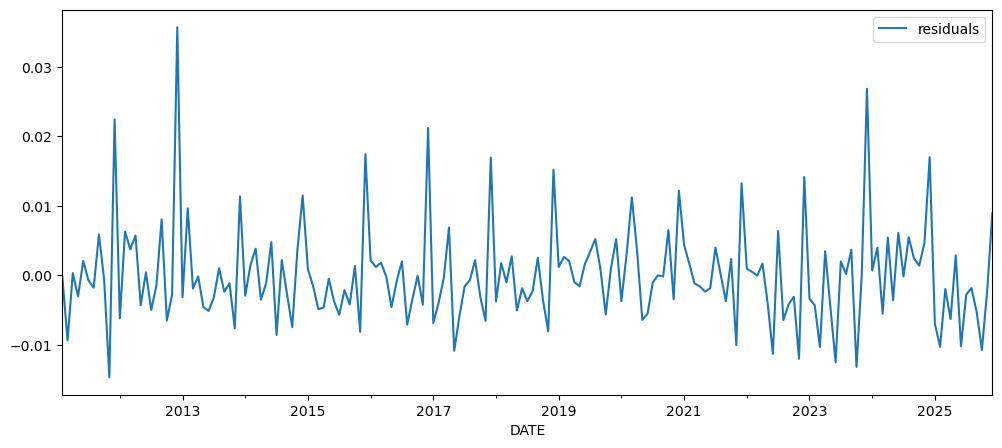

In [43]:
#plot residuals
residuals = model.resid

DATA['residuals'] = residuals

DATA.plot(x="DATE", y="residuals", kind="line", figsize=(12, 5))

# compute volatility
sigma = statistics.stdev(residuals)
print(f'Sigma is: {sigma}')

In [44]:
resid_samp_mean = residuals.mean()
resid_samp_std = np.sqrt(residuals.var())

# KOLMOGOROV-SMIRNOV test for Normality
#H0: The data is normally distributed

from scipy.stats import kstest

stat,p=kstest(residuals,'norm',args=(resid_samp_mean, resid_samp_std),alternative='two-sided')
print('KS_test=%.3f, p=%.3f\n'%(stat,p))
#reject NULL; residuals are not normal



# SHAPIRO-WILK test for Normality
#H0: The data is normally distributed
from scipy.stats import shapiro

stat,p=shapiro(residuals)
print('SW_test=%.3f, p=%.3f\n'%(stat,p))
#reject NULL; residuals are not normal


KS_test=0.115, p=0.016

SW_test=0.902, p=0.000



## In sample fit
The estimated growth rate $\tilde{y}(t)$ is bounded by lower and upper limits of the forecasting interval $\pm \sigma \cdot q_{(p)}$

Where $\sigma$ is the estimated volatility of the model (residuals' standard deviation) and $\ q_{(p)}$ is the standard normal $z$ with probability $p$

$$
\tilde{y}(t) = \mu_t \pm \sigma \cdot q_{(p)}
$$

In [45]:
fit_plot = DATA.loc[model.fittedvalues.index, ["DATE", "growth_rate_per_capita"]].copy()

fit_plot["fitted_growth_rate"] = model.fittedvalues
fit_plot["DATE"] = pd.to_datetime(fit_plot["DATE"])

In [46]:
#determine bouondaries of forecasting interval (1%, 99%)
# 1% and 99% standard normal quantiles

from scipy.stats import norm

z_1 = norm.ppf(0.01)
z_99 = norm.ppf(0.99)


fit_plot["lower_bound"] = fit_plot["fitted_growth_rate"] + z_1 * resid_samp_std
fit_plot["upper_bound"] = fit_plot["fitted_growth_rate"] + z_99 * resid_samp_std

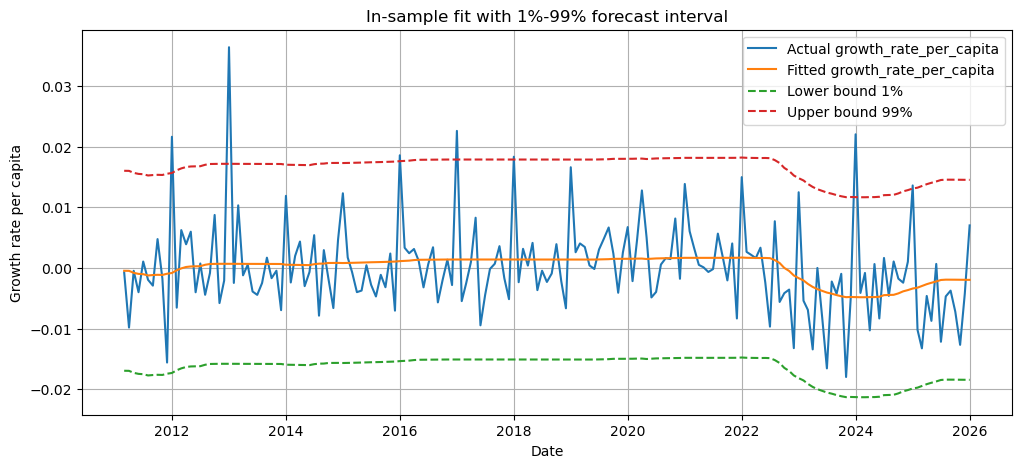

In [47]:
plt.figure(figsize=(12, 5))

plt.plot(
    fit_plot["DATE"],
    fit_plot["growth_rate_per_capita"],
    label="Actual growth_rate_per_capita"
)

plt.plot(
    fit_plot["DATE"],
    fit_plot["fitted_growth_rate"],
    label="Fitted growth_rate_per_capita"
)

plt.plot(
    fit_plot["DATE"],
    fit_plot["lower_bound"],
    linestyle="--",
    label="Lower bound 1%"
)

plt.plot(
    fit_plot["DATE"],
    fit_plot["upper_bound"],
    linestyle="--",
    label="Upper bound 99%"
)

plt.xlabel("Date")
plt.ylabel("Growth rate per capita")
plt.title("In-sample fit with 1%-99% forecast interval")
plt.legend()
plt.grid(True)
plt.show()

###
The fitted growth rate is almost flat around 0 given a relatively low $R^2$ (7.3%) of the model

# Stable amount and liquidity profile

The stable balance is determined using the Minimum Probable Amount (MPA) methodology. It is defined as the 99% lower bound of the forecast interval of total volumes, representing the level below which the balance is statistically unlikely to fall.

Recall the forecasting interval of the the estimated growth rate $\tilde{y}(t)$:

$$
\tilde{y}(t) = \mu_t \pm \sigma \cdot q_{(p)}
$$

The stable component is determined as:
$$
\mathrm{Stable}(t) = Volume(t-1) \cdot \exp \left( \mu_t + \sigma \cdot q_{(0.01)} \right)
$$

The lower the model's volatility $\sigma$, the more stable (and slower) is the decay of the stable component.

The drift parameter $\mu_t$ determines the speed of the decay, and is caped by 0. In the estimated model $\mu_t$ is solely driven by the market rate Euribor 1M, with a coefficient of -0.1467. A 1% increase in market rate will decrease the expected growth rate by 0.1467%, reducing therefore the stable component and accelerating its decay.

The drift parameter $\mu_t$ can be conditional. In a conditional case the out-of-sample market rates are proxied by forward curves. 
In an unconditional case the $\mu_t$ is constant: it can be the average market rate or the last observed market rate.
Given the illustrative purpose of this workbook, $\mu_t$ is unconditional and is set equal to the average rate. 

The period $t$ is set to 360 months (30 years).

In [48]:
DATA

,DATE,amount,n_of_accounts,Euribor_1M,customer_rate,Spread,dCovid,Volume_PerCapita,LogVolume_PerCapita,growth_rate_per_capita,residuals
0,2011-02-28,819713012000,35169276.3333,0.0089,0.0024,0.0154,0,23307.6451,10.0565,-0.0007,-0.0003
1,2011-03-31,812818655000,35217904.5000,0.0090,0.0024,0.0167,0,23079.6996,10.0467,-0.0098,-0.0094
2,2011-04-30,813558974000,35266532.6667,0.0113,0.0026,0.0150,0,23068.8676,10.0462,-0.0005,0.0003
3,2011-05-31,811428024000,35315160.8333,0.0124,0.0027,0.0170,0,22976.7614,10.0422,-0.0040,-0.0030
4,2011-06-30,813408017000,35363789.0000,0.0128,0.0029,0.0193,0,23001.1557,10.0433,0.0011,0.0021
...,...,...,...,...,...,...,...,...,...,...,...
174,2025-08-31,1231230265000,51419361.3333,0.0189,0.0016,0.0087,0,23944.8767,10.0835,-0.0037,-0.0018
175,2025-09-30,1232227756000,51833018.2500,0.0190,0.0016,0.0087,0,23773.0273,10.0763,-0.0072,-0.0053
176,2025-10-31,1226414269000,52246675.1667,0.0191,0.0016,0.0082,0,23473.5371,10.0636,-0.0127,-0.0107
177,2025-11-30,1230886279000,52660332.0833,0.0191,0.0016,0.0080,0,23374.0698,10.0594,-0.0042,-0.0023


In [49]:
params = model.params.copy()

intercept_name = "Intercept" if "Intercept" in params.index else "const"
intercept = params[intercept_name]

betas = params.drop(intercept_name)

# Check that all model variables are in DATA
missing_vars = betas.index.difference(DATA.columns)
if len(missing_vars) > 0:
    raise KeyError(f"Following variables are missing from dataframe 'DATA': {list(missing_vars)}")

# Compute means of the significant variables
mean = DATA[betas.index].mean()
mean

Euribor_1M   0.0054
dtype: float64

In [50]:
# Keep only the last row of DATA
last_row = DATA.tail(1).copy()

# Make sure DATE is datetime
last_date = pd.to_datetime(last_row["DATE"].iloc[0])

# Create 360 copies of the last row
DATA_future = pd.concat([last_row] * 360, ignore_index=True)

DATA_future["DATE"] = pd.date_range(
    start=last_date,
    periods=360,
    freq="ME"
)

DATA_future

,DATE,amount,n_of_accounts,Euribor_1M,customer_rate,Spread,dCovid,Volume_PerCapita,LogVolume_PerCapita,growth_rate_per_capita,residuals
0,2025-12-31,1249289895000,53073989.0000,0.0192,0.0016,0.0074,0,23538.6471,10.0664,0.0070,0.0090
1,2026-01-31,1249289895000,53073989.0000,0.0192,0.0016,0.0074,0,23538.6471,10.0664,0.0070,0.0090
2,2026-02-28,1249289895000,53073989.0000,0.0192,0.0016,0.0074,0,23538.6471,10.0664,0.0070,0.0090
3,2026-03-31,1249289895000,53073989.0000,0.0192,0.0016,0.0074,0,23538.6471,10.0664,0.0070,0.0090
4,2026-04-30,1249289895000,53073989.0000,0.0192,0.0016,0.0074,0,23538.6471,10.0664,0.0070,0.0090
...,...,...,...,...,...,...,...,...,...,...,...
355,2055-07-31,1249289895000,53073989.0000,0.0192,0.0016,0.0074,0,23538.6471,10.0664,0.0070,0.0090
356,2055-08-31,1249289895000,53073989.0000,0.0192,0.0016,0.0074,0,23538.6471,10.0664,0.0070,0.0090
357,2055-09-30,1249289895000,53073989.0000,0.0192,0.0016,0.0074,0,23538.6471,10.0664,0.0070,0.0090
358,2055-10-31,1249289895000,53073989.0000,0.0192,0.0016,0.0074,0,23538.6471,10.0664,0.0070,0.0090


In [51]:
matching_cols = mean.index.intersection(DATA_future.columns)

# Substitute matching columns with their mean values
for col in matching_cols:
    DATA_future[col] = mean.loc[col]

DATA_future.head()

,DATE,amount,n_of_accounts,Euribor_1M,customer_rate,Spread,dCovid,Volume_PerCapita,LogVolume_PerCapita,growth_rate_per_capita,residuals
0,2025-12-31,1249289895000,53073989.0000,0.0054,0.0016,0.0074,0,23538.6471,10.0664,0.0070,0.0090
1,2026-01-31,1249289895000,53073989.0000,0.0054,0.0016,0.0074,0,23538.6471,10.0664,0.0070,0.0090
2,2026-02-28,1249289895000,53073989.0000,0.0054,0.0016,0.0074,0,23538.6471,10.0664,0.0070,0.0090
3,2026-03-31,1249289895000,53073989.0000,0.0054,0.0016,0.0074,0,23538.6471,10.0664,0.0070,0.0090
4,2026-04-30,1249289895000,53073989.0000,0.0054,0.0016,0.0074,0,23538.6471,10.0664,0.0070,0.0090


In [52]:
cols_to_keep = ["DATE", "amount"] + list(mean.index)

# Keep only columns that exist in DATA_future
cols_to_keep = [col for col in cols_to_keep if col in DATA_future.columns]

DATA_future = DATA_future[cols_to_keep].copy()
DATA_future.iloc[1:, DATA_future.columns.get_loc("amount")] = np.nan

DATA_future

,DATE,amount,Euribor_1M
0,2025-12-31,1249289895000.0000,0.0054
1,2026-01-31,NaN,0.0054
2,2026-02-28,NaN,0.0054
3,2026-03-31,NaN,0.0054
4,2026-04-30,NaN,0.0054
...,...,...,...
355,2055-07-31,NaN,0.0054
356,2055-08-31,NaN,0.0054
357,2055-09-30,NaN,0.0054
358,2055-10-31,NaN,0.0054


In [53]:
# Compute drift 
drift_raw = intercept + (betas * DATA[betas.index].mean()).sum()

# Drift caped to 0 
drift = min(drift_raw, 0)
print(f"the drift is: {drift}")

DATA_future["drift"] = drift
DATA_future["cumulative_drift"] = DATA_future["drift"].cumsum()
DATA_future

the drift is: 0


,DATE,amount,Euribor_1M,drift,cumulative_drift
0,2025-12-31,1249289895000.0000,0.0054,0,0
1,2026-01-31,NaN,0.0054,0,0
2,2026-02-28,NaN,0.0054,0,0
3,2026-03-31,NaN,0.0054,0,0
4,2026-04-30,NaN,0.0054,0,0
...,...,...,...,...,...
355,2055-07-31,NaN,0.0054,0,0
356,2055-08-31,NaN,0.0054,0,0
357,2055-09-30,NaN,0.0054,0,0
358,2055-10-31,NaN,0.0054,0,0


In [54]:
DATA_future["z_1"] = z_1
DATA_future["volatility"] = resid_samp_std

## Compute Stable amount at $t = 0$
$$
\mathrm{Stable}(t) = Volume(t-1) \cdot \exp \left( \mu_t + \sigma \cdot q_{(0.01)} \right)
$$

In [55]:
DATA_future["t"] = range(-1, len(DATA_future) - 1)
DATA_future["Stable_MPA"] = 0
DATA_future["Stable_MPA"] = DATA_future["Stable_MPA"].astype(float)
DATA_future

,DATE,amount,Euribor_1M,drift,cumulative_drift,z_1,volatility,t,Stable_MPA
0,2025-12-31,1249289895000.0000,0.0054,0,0,-2.3263,0.0071,-1,0.0000
1,2026-01-31,NaN,0.0054,0,0,-2.3263,0.0071,0,0.0000
2,2026-02-28,NaN,0.0054,0,0,-2.3263,0.0071,1,0.0000
3,2026-03-31,NaN,0.0054,0,0,-2.3263,0.0071,2,0.0000
4,2026-04-30,NaN,0.0054,0,0,-2.3263,0.0071,3,0.0000
...,...,...,...,...,...,...,...,...,...
355,2055-07-31,NaN,0.0054,0,0,-2.3263,0.0071,354,0.0000
356,2055-08-31,NaN,0.0054,0,0,-2.3263,0.0071,355,0.0000
357,2055-09-30,NaN,0.0054,0,0,-2.3263,0.0071,356,0.0000
358,2055-10-31,NaN,0.0054,0,0,-2.3263,0.0071,357,0.0000


In [56]:
#compute first MPA (t=0)
row = DATA_future.index[1]

stable_mpa_value = (
    DATA_future.loc[DATA_future.index[0], "amount"]
    * np.exp(
        DATA_future.loc[row, "drift"]
        + DATA_future.loc[row, "z_1"] * DATA_future.loc[row, "volatility"]
    )
)

DATA_future.loc[row, "Stable_MPA"] = stable_mpa_value
DATA_future

,DATE,amount,Euribor_1M,drift,cumulative_drift,z_1,volatility,t,Stable_MPA
0,2025-12-31,1249289895000.0000,0.0054,0,0,-2.3263,0.0071,-1,0.0000
1,2026-01-31,NaN,0.0054,0,0,-2.3263,0.0071,0,1228859523255.7527
2,2026-02-28,NaN,0.0054,0,0,-2.3263,0.0071,1,0.0000
3,2026-03-31,NaN,0.0054,0,0,-2.3263,0.0071,2,0.0000
4,2026-04-30,NaN,0.0054,0,0,-2.3263,0.0071,3,0.0000
...,...,...,...,...,...,...,...,...,...
355,2055-07-31,NaN,0.0054,0,0,-2.3263,0.0071,354,0.0000
356,2055-08-31,NaN,0.0054,0,0,-2.3263,0.0071,355,0.0000
357,2055-09-30,NaN,0.0054,0,0,-2.3263,0.0071,356,0.0000
358,2055-10-31,NaN,0.0054,0,0,-2.3263,0.0071,357,0.0000


In [57]:
print(f'Stable deposits are {100*stable_mpa_value/DATA_future["amount"].iloc[0]}% of total deposits')

Stable deposits are 98.36464123931401% of total deposits


### Methodological Note
The extremely low volatility of the estimated model and the drift ${u=0}$ lead to stable deposits equal to 98.4%. The stable deposits are amortized according to the MPA model, while the non-stable component has an overnight maturity.  

EBA IRRBB RTS (EBA/RTS/2022/09, Article 7) require to determine the core proportion of stable deposits that is unlikely to reprice even under significant changes in market rates. 
https://www.eba.europa.eu/sites/default/files/document_library/Publications/Draft%20Technical%20Standards/2022/EBA-RTS-2022-09%20RTS%20on%20SA/1041755/Final%20draft%20RTS%20on%20SA.pdf).

Article 7 of the EBA IRRBB RTS determines the core amount according to the following formula:  

$$
\mathrm{Core} = \mathrm{Stable} \cdot (1 - \beta)
$$

$\beta$ is the "pass-through" rate estimated in the customer rate model. It is the long term elasticity of the customer rate to the changes in the market rate. From the customer rate (long term) model $\beta = 0.0589$.

The Core component repricecs at the model's estimated maturity, with a 5 year cap set by EBA IRRBB RTS (retail transactional deposits). The regulator further caps the Core component at 90% of total deposits.

The Non-Core component has an overnight maturity (EBA IRRBB RTS, Article 10)


```mermaid
flowchart TD

    A["Total Volume NMD"]

    A --> B["Stable<br/>(S = 98.3%)"]
    A --> C["Non-Stable<br/>(NS = 1.7%)"]

    B --> D["Non repricing<br/>(1 - P = 94.1%)"]
    B --> E["Repricing<br/>(P = 5.9%)"]

    D --> F["Core<br/>(S · (1 - P))"]

    C --> G["Non-Core<br/>(NS + S · P)"]
    E --> G

    subgraph S1[" "]
        B
        C
    end

    subgraph S2[" "]
        D
        E
    end

    style A fill:#d9d9d9,stroke:#333,stroke-width:1px
    style B fill:#d9d9d9,stroke:#333,stroke-width:1px
    style C fill:#d9d9d9,stroke:#333,stroke-width:1px
    style D fill:#d9d9d9,stroke:#333,stroke-width:1px
    style E fill:#d9d9d9,stroke:#333,stroke-width:1px
    style F fill:#d9d9d9,stroke:#333,stroke-width:1px
    style G fill:#d9d9d9,stroke:#333,stroke-width:1px
```

In [58]:
beta = 0.0589 #from the customer rate (long-term)
amount = DATA_future.loc[DATA_future.index[0], "amount"]

core = min(stable_mpa_value*(1-beta), 0.9*amount)
print(f'core deposits are {100*core/amount}% of total deposits')

core deposits are 90.0% of total deposits


In [59]:
non_core = (max(stable_mpa_value * beta, 0.1 * amount) + #stable repricing component
            (amount - stable_mpa_value if 0.1 * amount < stable_mpa_value * beta else 0)) # non-stable component

print(f'non-core deposits are {100*non_core/DATA_future["amount"].iloc[0]}% of total deposits')

non-core deposits are 10.0% of total deposits


In [60]:
#check (must return 0)
amount - core - non_core

np.float64(0.0)

In [61]:
DATA_future.loc[row, "core"] = core
DATA_future.loc[row, "non-core"] = non_core
DATA_future

,DATE,amount,Euribor_1M,drift,cumulative_drift,z_1,volatility,t,Stable_MPA,core,non-core
0,2025-12-31,1249289895000.0000,0.0054,0,0,-2.3263,0.0071,-1,0.0000,NaN,NaN
1,2026-01-31,NaN,0.0054,0,0,-2.3263,0.0071,0,1228859523255.7527,1124360905500.0000,124928989500.0000
2,2026-02-28,NaN,0.0054,0,0,-2.3263,0.0071,1,0.0000,NaN,NaN
3,2026-03-31,NaN,0.0054,0,0,-2.3263,0.0071,2,0.0000,NaN,NaN
4,2026-04-30,NaN,0.0054,0,0,-2.3263,0.0071,3,0.0000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
355,2055-07-31,NaN,0.0054,0,0,-2.3263,0.0071,354,0.0000,NaN,NaN
356,2055-08-31,NaN,0.0054,0,0,-2.3263,0.0071,355,0.0000,NaN,NaN
357,2055-09-30,NaN,0.0054,0,0,-2.3263,0.0071,356,0.0000,NaN,NaN
358,2055-10-31,NaN,0.0054,0,0,-2.3263,0.0071,357,0.0000,NaN,NaN


## Compute Core amount at $t = 1, 2, 3, \ldots$
Since we don't have an estimate of the future total volumes, the formula:
$$
\mathrm{Stable}(t) = Volume(t-1) \cdot \exp \left( \mu_t + \sigma \cdot q_{(0.01)} \right)
$$

cannot be used to determine the core amount at time $t = 1, 2, 3, \ldots$ 

Instead, the MPA core amount at $t = 1, 2, 3, \ldots$ is determined according to the following formula:

$$
\mathrm{Core}(t) = \mathrm{Core}_{t=0} \cdot \exp\left[
\left(\mu_t^* - \frac{\sigma^2}{2}\right)t 
+ q_{(0.01)} \cdot \sqrt{t} \cdot \sigma
\right]
$$


Where $u_t^*$ is the cumulative drift $u_t$ up to time $t$ included.





In [62]:
Core_t0 = DATA_future.loc[DATA_future["t"] == 0, "core"].iloc[0]

mask = DATA_future["t"] >= 1

In [63]:
DATA_future.loc[mask, "core"] = (
    Core_t0
    * np.exp(
        DATA_future.loc[mask, "cumulative_drift"]                        
        - (DATA_future.loc[mask, "volatility"] ** 2 / 2) * DATA_future.loc[mask, "t"]
        + DATA_future.loc[mask, "z_1"] * np.sqrt(DATA_future.loc[mask, "t"]) * DATA_future.loc[mask, "volatility"]
    )
)
DATA_future

,DATE,amount,Euribor_1M,drift,cumulative_drift,z_1,volatility,t,Stable_MPA,core,non-core
0,2025-12-31,1249289895000.0000,0.0054,0,0,-2.3263,0.0071,-1,0.0000,NaN,NaN
1,2026-01-31,NaN,0.0054,0,0,-2.3263,0.0071,0,1228859523255.7527,1124360905500.0000,124928989500.0000
2,2026-02-28,NaN,0.0054,0,0,-2.3263,0.0071,1,0.0000,1105945790612.0872,NaN
3,2026-03-31,NaN,0.0054,0,0,-2.3263,0.0071,2,0.0000,1098390461552.3691,NaN
4,2026-04-30,NaN,0.0054,0,0,-2.3263,0.0071,3,0.0000,1092621684213.8577,NaN
...,...,...,...,...,...,...,...,...,...,...,...
355,2055-07-31,NaN,0.0054,0,0,-2.3263,0.0071,354,0.0000,817166953560.2393,NaN
356,2055-08-31,NaN,0.0054,0,0,-2.3263,0.0071,355,0.0000,816788697567.4380,NaN
357,2055-09-30,NaN,0.0054,0,0,-2.3263,0.0071,356,0.0000,816411119812.6642,NaN
358,2055-10-31,NaN,0.0054,0,0,-2.3263,0.0071,357,0.0000,816034217399.5514,NaN


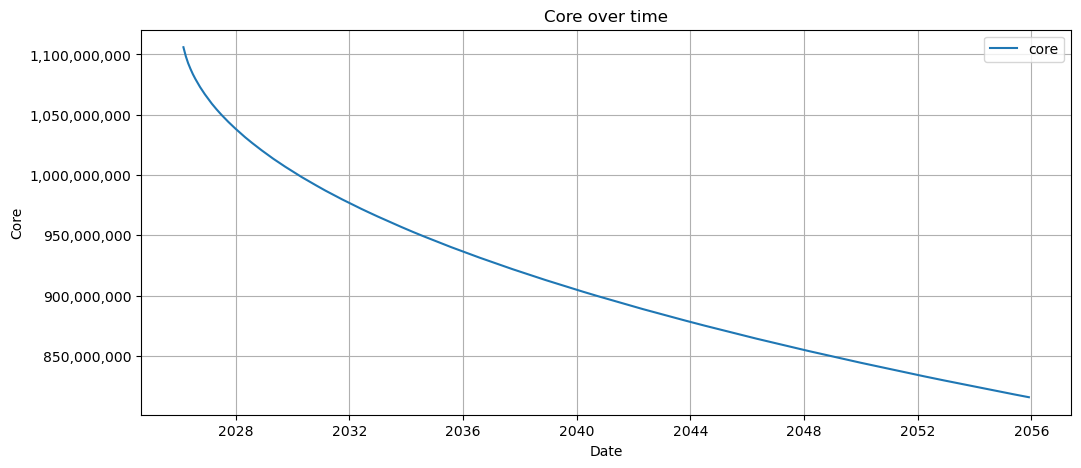

In [64]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 5))
plt.plot(DATA_future.loc[mask, "DATE"], DATA_future.loc[mask, "core"]/1000, label="core")

plt.xlabel("Date")
plt.ylabel("Core")
plt.title("Core over time")
plt.grid(True)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f}")
)
plt.legend()
plt.show()

### 
Given the extremely low volatility and zero drift estimated by the model, the decay profile of the core component is slow.

After 30 years, only EUR 309 billion of the initial core balance has been amortized, leaving a residual amount of EUR 815 billion.

The aim of this workbook is to provide an illustrative example of an NMD model estimation. The model is estimated on a consolidated national public data, which are generally more stable, rather than a real-case application based on private bank data, which would typically be more volatile.

The Mean Life measures the expected amount of time over which the amortisation of the stable component is permitted. In practice, Mean Life sets the maximum allowable maturity for the amortisation of the stable component. Mean Life depends on the estimated historical volatility, drift and the confidence level.

## Mean Life computation
The Mean Life is derived from the expression of MPA for $t = 1, 2, 3, \ldots$. 
Recall that: 

$$
\mathrm{Core}(t) = \mathrm{Core}_{t=0} \cdot \exp\left[
\left(\mu_t^* - \frac{\sigma^2}{2}\right)t 
+ q_{(0.01)} \cdot \sqrt{t} \cdot \sigma
\right]
$$

and

$$
{S_v}(t) = \exp\left[
\left(\mu_t^* - \frac{\sigma^2}{2}\right)t 
+ q_{(0.01)} \cdot \sqrt{t} \cdot \sigma
\right]
$$

${S_v}(t)$ represents the survival amount of the core balance at any given time  $t$.

The corresponding density function: $$
f_v(t) = -\frac{dS_v(t)}{dt}
$$ represent an instataneous time $t$ at which the entire amount of the deposit will "die". In economical terms $f_v(t)$ indicates the time when the deposit will be completely amortized.

Using the definition of the first moment of a random variable $t$, the expected time $E[t]$ at which the deposit will be paid off is given by following equation:

$$
E[t] = \int_{0}^{+\infty} t \cdot f_v(t) \, dt 
$$

$$
E[t] = \int_{0}^{+\infty} -t \cdot \exp\left[
\left(\mu_t^* - \frac{\sigma^2}{2}\right)t 
+ q_{(0.01)} \cdot \sqrt{t} \cdot \sigma
\right]\cdot \left[\mu_t^* - \frac{\sigma^2}{2} + q_{(0.01)}\cdot \frac{\sigma}{2\cdot\sqrt{t}}\right] dt
$$

The integral is computed with Mathematica. For the details see "Mean Life - Mathematica.pdf" stored in the repository.
The final expression of $E[t]$ is following:

$$
E[t]=
\frac{1}{\frac{\sigma^2}{2}-\mu_t}
+
\frac{q_{0.01}\sigma\sqrt{\pi}}{2\left(\frac{\sigma^2}{2}-\mu_t\right)^{3/2}}
\exp\!\left(
\frac{q_{0.01}^2\sigma^2}{4\left(\frac{\sigma^2}{2}-\mu_t\right)}
\right)
\left(
1+\operatorname{erf}\!\left(
\frac{q_{0.01}\sigma}{2\sqrt{\frac{\sigma^2}{2}-\mu_t}}
\right)
\right) 
$$

Where $erf$ is the error function


In [65]:
#compute Mean-Life
from scipy.special import erf

mu = DATA_future.loc[row, "drift"]         # μ_t
sigma = DATA_future.loc[row, "volatility"] # σ
q = DATA_future.loc[row, "z_1"]            # q_0.01

# Denominator term
A = (sigma**2 / 2) - mu

if A <= 0:
    E_t = np.nan
    print("Formula not valid because sigma^2 / 2 - mu <= 0")
else:
    E_t = (
        1 / A + (
            q * sigma * np.sqrt(np.pi)
            /
            (2 * A**(3 / 2))
        )
        *
        np.exp((q**2 * sigma**2)
            /
            (4 * A)
        )
        *
        (
            1 + erf(
                (q * sigma)
                /
                (2 * np.sqrt(A))
            )
        )
    )

print("E[t] =", E_t)

E[t] = 5061.72327493193


###
The data show an outlier Mean-Life (5061 months, ~421 years). The extremely long decay profile is due to the low volatility of the estimated model (sigma is 0.007), caused by a "smoothening" effect of the linear interpolation of deposits' amounts and the number of customer accounts.

In practice the ML sets the maximum maturity of the amortizing profile of the core component. 
Under the ML amortization profile, the non amortized amount (if any) at $t=ML$ is evenly allocated to all maturity buckets $t = 1, 2, 3, \ldots \ ML$. Under the ML amortization profile, the entire core amount will be completely amortized at $t=ML$.

Lastly user must be aware that regardless the modeled amortization, the Article 11 EBA IRRBB RTS (retail transactional deposits) caps the average maturity of the core component to 5 years (which the current model clearly overshoots by a high margin).